# Episode 3 — Feature selection and the leakage bug that fooled you

**Goal:** show that feature selection outside the cross-validation loop is data leakage that can inflate accuracy from chance to near-perfect on **pure noise** — and that L1 regularization makes the whole category of bugs disappear.

Follows on directly from Episode 2: we said *"standardize inside the CV loop, not before the split."* Today's episode is the same principle at 10x the stakes.


## Setup

Same `.venv` as episodes 1 and 2.


In [2]:
import sys
import importlib.metadata as md

print(f'python executable: {sys.executable}')
print()
for pkg in ('numpy', 'pandas', 'scikit-learn', 'matplotlib'):
    try:
        print(f'  {pkg:14s} {md.version(pkg)}')
    except md.PackageNotFoundError:
        print(f'  {pkg:14s} NOT INSTALLED  <- run: pip install -r requirements.txt')

print()
print('OK: .venv is active' if '.venv' in sys.executable else 'WARNING: not in .venv')


python executable: /Library/Developer/CommandLineTools/usr/bin/python3

  numpy          2.0.2
  pandas         2.3.3
  scikit-learn   1.6.1
  matplotlib     3.9.4



In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RNG = 0
rng = np.random.default_rng(RNG)
np.set_printoptions(precision=4, suppress=True)


## Primer — what is a "CV loop," and how does it tie back to scaling?

Everything in this episode hinges on understanding cross-validation as a *loop*, not a single split. If you have that already, skip. Otherwise, read this.

### Train/test split — the baseline

The simplest honest evaluation is a **train/test split**: hold out (say) 20% of your data, train on the rest, score on the held-out 20%. One number, one shot. Two problems: the score depends heavily on *which* 20% you picked (high variance on small data), and you're only using 80% of your data to train.

### K-fold cross-validation — the loop

**K-fold CV** fixes both. Split the data into K equal chunks ("folds"). Then loop:

```
for fold_i in range(K):
    train_set = all folds EXCEPT fold_i
    test_set  = fold_i
    fit model on train_set
    score model on test_set
final_score = mean of the K scores
```

With K=5 you use 80% for training in *each* iteration and every sample gets used for testing exactly once. Standard values are K=5 or K=10. `StratifiedKFold` (used in this notebook) additionally preserves the label balance in each fold — important for classification.

**"The CV loop"** is that `for fold_i in range(K)` loop. When we say *"inside the CV loop"* we mean **operations that get repeated for each of the K iterations, using only that iteration's training folds.** *"Outside the CV loop"* means the operation runs *once, on all the data, before splitting.*

### The one-liner rule (repeated from Ep. 2)

> **Any operation that looks at `y` must live inside the CV loop.**

Or, more precisely: any *fittable* preprocessing step must be refit **on each fold's training data only** — never on the whole dataset before splitting. Otherwise information from the test folds leaks into the trained pipeline.

### How this ties back to scaling (Ep. 2)

In Ep. 2 we said "standardize before the model, but inside the CV loop." The mechanism was:

- `StandardScaler` computes `mean` and `std` **from the data you fit it on.**
- If you fit it on the whole dataset before splitting, the mean and std it stores were computed using the test folds too — a mild form of leakage. Usually harmless in practice, because the test-set contribution to the aggregate mean/std is small.
- The correct pattern was: put `StandardScaler` in a `Pipeline` with the model, hand the pipeline to `cross_val_score`. Now the scaler gets refit on each fold's training set only.

Ep. 3 is the **same rule, higher stakes.** Where scaling reads only column-level statistics (mean, std), feature selection reads the **labels themselves** — and can spuriously discover "significant" columns among thousands of noise ones. The leakage magnitude jumps from ~1pp (scaling) to 40pp (selection).

### Quick vocabulary

| Term | Meaning |
|---|---|
| **Fold** | One of the K equal-sized chunks the data is split into |
| **Train set (per fold)** | The K−1 chunks used to fit the model in one iteration |
| **Test / validation fold** | The 1 chunk held out for scoring in one iteration |
| **CV loop** | The K-iteration loop that trains + scores K times |
| **Inside the CV loop** | The operation is refit for every iteration, on the training folds only |
| **Outside the CV loop** | The operation runs once, before any splitting, on the full dataset |
| **`Pipeline`** | sklearn container that makes a sequence of fittable steps behave as one estimator — so `cross_val_score` refits all of them together |

With that vocabulary in hand, Part 1 will show what "outside the CV loop" costs when the operation looks at `y`.

## Part 1 — Pure noise, and the 40-point lie

To isolate leakage cleanly we need a dataset where there is **no signal to find.** That means: random labels, random features, no relationship whatsoever between `X` and `y`.

**True cross-validated accuracy on this dataset must be 50%.** Anything above 50% is either luck or a bug.

Setup:
- `n = 200` samples
- `p = 10 000` features (all pure Gaussian noise)
- `y` = random 0/1 labels


In [3]:
n_samples = 200
n_features = 10_000

X_noise = rng.standard_normal(size=(n_samples, n_features))
y_random = rng.integers(0, 2, size=n_samples)

print(f'X shape: {X_noise.shape}')
print(f'label balance: {y_random.mean():.2f}')
print(f'ground truth: there is NO signal here. Correct CV accuracy must be ~0.50.')


X shape: (200, 10000)
label balance: 0.55
ground truth: there is NO signal here. Correct CV accuracy must be ~0.50.


### The wrong way

Run `SelectKBest` on the **entire dataset** to pick the top 100 features. Then cross-validate a linear model on those 100 features.


In [4]:
K = 100
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)

# WRONG: selector fitted on all of X and y, before CV splits happen.
selector_wrong = SelectKBest(f_classif, k=K)
X_pre_selected = selector_wrong.fit_transform(X_noise, y_random)

scores_wrong = cross_val_score(
    LogisticRegression(max_iter=5000),
    X_pre_selected, y_random, cv=cv,
)

print(f'=== WRONG: selection outside the CV loop ===')
print(f'per-fold scores: {scores_wrong}')
print(f'mean accuracy:   {scores_wrong.mean():.3f}')
print()
print(f'Expected: 0.50 (there is no signal).')
print(f'Reported: {scores_wrong.mean():.3f}. That gap is the leakage.')


=== WRONG: selection outside the CV loop ===
per-fold scores: [0.95  1.    0.975 0.95  0.975]
mean accuracy:   0.970

Expected: 0.50 (there is no signal).
Reported: 0.970. That gap is the leakage.


/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features

### What just happened

`SelectKBest` scored every one of the 10 000 noise columns against the label using the *entire dataset*, and picked the 100 whose noise happened to correlate with the labels best. Among 10 000 random columns, dozens will correlate with any target purely by chance — just by counting coincidences.

When we then cross-validated, those 100 columns arrived **already pre-screened for correlation with the labels** — including the labels of each test fold, because the whole dataset was in the selector's input.

> **The selector peeked at the test labels. Then we asked the model how well it did on those same test labels. The answer was rigged.**


### The fix: `Pipeline` puts selection inside the CV loop

Wrap the selector and the model as a `Pipeline`, hand the whole thing to `cross_val_score`. Now the selector gets refit on each fold's **training set only**. Test folds stay invisible until scoring.

Same K, same selector, same model, same CV splitter. Two lines of code changed.


In [5]:
pipe = Pipeline([
    ('select', SelectKBest(f_classif, k=K)),
    ('clf',    LogisticRegression(max_iter=5000)),
])

scores_right = cross_val_score(pipe, X_noise, y_random, cv=cv)

print(f'=== RIGHT: selection inside the CV loop (via Pipeline) ===')
print(f'per-fold scores: {scores_right}')
print(f'mean accuracy:   {scores_right.mean():.3f}')
print()
print(f'{"WRONG accuracy:":<20} {scores_wrong.mean():.3f}')
print(f'{"RIGHT accuracy:":<20} {scores_right.mean():.3f}')
print(f'{"Truth:":<20} 0.500')
print(f'{"Inflation:":<20} {(scores_wrong.mean() - scores_right.mean())*100:+.1f} percentage points')


=== RIGHT: selection inside the CV loop (via Pipeline) ===
per-fold scores: [0.65  0.5   0.625 0.525 0.55 ]
mean accuracy:   0.570

WRONG accuracy:      0.970
RIGHT accuracy:      0.570
Truth:               0.500
Inflation:           +40.0 percentage points


/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features

### The one-liner rule

> **Any operation that looks at `y` must live inside the CV loop.**

Scaling *often* gets away with breaking this rule (test-set mean and std usually don't leak much signal). Feature selection, target encoding, and threshold-based rules *never* do — they read the labels directly.

**In sklearn, the rule becomes:** put every fittable preprocessing step in a `Pipeline`, and let `cross_val_score` drive the pipeline.


## Part 2 — Sweep K to see leakage across the whole range

The single K=100 number could be a fluke. Sweep K and confirm the leakage is systematic — not a boundary effect.


In [6]:
K_values = [5, 20, 50, 100, 300, 1000, 3000]
wrong_means, right_means = [], []

for k in K_values:
    # Wrong: pre-select on all data.
    sel = SelectKBest(f_classif, k=k)
    X_pre = sel.fit_transform(X_noise, y_random)
    s_wrong = cross_val_score(LogisticRegression(max_iter=5000),
                              X_pre, y_random, cv=cv)

    # Right: select inside the pipeline.
    p = Pipeline([('sel', SelectKBest(f_classif, k=k)),
                  ('clf', LogisticRegression(max_iter=5000))])
    s_right = cross_val_score(p, X_noise, y_random, cv=cv)

    wrong_means.append(s_wrong.mean())
    right_means.append(s_right.mean())
    print(f'K={k:>5d}  WRONG={s_wrong.mean():.3f}  RIGHT={s_right.mean():.3f}  '
          f'inflation={100*(s_wrong.mean()-s_right.mean()):+.1f}pp')


K=    5  WRONG=0.690  RIGHT=0.505  inflation=+18.5pp
K=   20  WRONG=0.865  RIGHT=0.530  inflation=+33.5pp
K=   50  WRONG=0.950  RIGHT=0.575  inflation=+37.5pp
K=  100  WRONG=0.970  RIGHT=0.570  inflation=+40.0pp
K=  300  WRONG=1.000  RIGHT=0.535  inflation=+46.5pp


/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features

K= 1000  WRONG=1.000  RIGHT=0.560  inflation=+44.0pp
K= 3000  WRONG=1.000  RIGHT=0.535  inflation=+46.5pp


/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w =

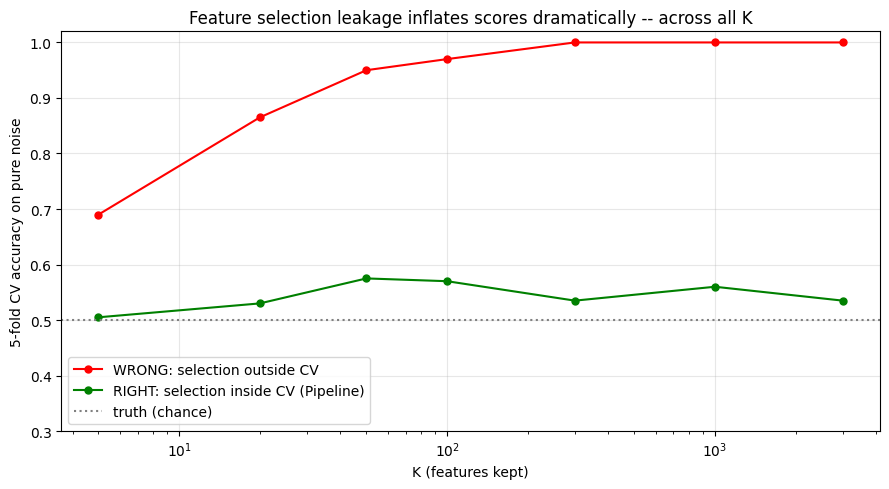


The RIGHT curve hovers near 0.50 -- because there IS no signal.
The WRONG curve reports high accuracy at every K. Every one of those numbers is a lie.


In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(K_values, wrong_means, 'r.-', label='WRONG: selection outside CV', markersize=10)
ax.plot(K_values, right_means, 'g.-', label='RIGHT: selection inside CV (Pipeline)', markersize=10)
ax.axhline(0.5, color='gray', linestyle=':', label='truth (chance)')
ax.set_xscale('log')
ax.set_xlabel('K (features kept)')
ax.set_ylabel('5-fold CV accuracy on pure noise')
ax.set_title('Feature selection leakage inflates scores dramatically -- across all K')
ax.set_ylim(0.3, 1.02)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print()
print('The RIGHT curve hovers near 0.50 -- because there IS no signal.')
print('The WRONG curve reports high accuracy at every K. Every one of those numbers is a lie.')


## Part 3 — When there *is* real signal, leakage is subtler but still lies

You might object: *"my data isn't pure noise."* Fair. Let's use the real breast cancer dataset (569 samples, 30 real features, near-linearly-separable), and bolt on 20 000 noise columns.

Because the real signal is very strong, both methods will land in the mid-90s. But leakage still inflates scores — and worse, it **corrupts which features you think matter.**


In [8]:
X_real, y = load_breast_cancer(return_X_y=True)
n_real = X_real.shape[1]
X_extra_noise = rng.standard_normal(size=(X_real.shape[0], 20_000))
X_all = np.hstack([X_real, X_extra_noise])

print(f'X shape: {X_all.shape}   ({n_real} real + 20 000 noise)')
print(f'noise ratio: {20_000 / X_all.shape[1]:.2%}')


X shape: (569, 20030)   (30 real + 20 000 noise)
noise ratio: 99.85%


In [9]:
K = 100

# WRONG
sel_w = SelectKBest(f_classif, k=K)
X_sel_w = sel_w.fit_transform(X_all, y)
sc_w = cross_val_score(LogisticRegression(max_iter=5000), X_sel_w, y, cv=cv)

# RIGHT
p_r = Pipeline([('sel', SelectKBest(f_classif, k=K)),
                ('clf', LogisticRegression(max_iter=5000))])
sc_r = cross_val_score(p_r, X_all, y, cv=cv)

# What did the WRONG selector actually keep?
selected_wrong = np.where(sel_w.get_support())[0]
noise_kept = (selected_wrong >= n_real).sum()

print(f'=== Real signal + 20 000 noise columns ===')
print(f'WRONG (selection outside CV): {sc_w.mean():.3f}')
print(f'RIGHT (selection inside CV):  {sc_r.mean():.3f}')
print(f'inflation:                    {(sc_w.mean()-sc_r.mean())*100:+.1f} percentage points')
print()
print(f'Of the {K} features WRONG selection kept:')
print(f'  {K - noise_kept} are real ({(K-noise_kept)/K:.0%})')
print(f'  {noise_kept} are noise columns that spuriously correlated ({noise_kept/K:.0%})')
print()
print('Even though the accuracy gap looks small, three-quarters of the "important"')
print('features are noise. If you were doing feature *interpretation* -- not just')
print('prediction -- you would be reporting garbage discoveries as biology.')


/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features

=== Real signal + 20 000 noise columns ===
WRONG (selection outside CV): 0.967
RIGHT (selection inside CV):  0.930
inflation:                    +3.7 percentage points

Of the 100 features WRONG selection kept:
  25 are real (25%)
  75 are noise columns that spuriously correlated (75%)

Even though the accuracy gap looks small, three-quarters of the "important"
features are noise. If you were doing feature *interpretation* -- not just
prediction -- you would be reporting garbage discoveries as biology.


/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: inva

### Two ways leakage hurts you

1. **Prediction accuracy is inflated.** How much depends on how much real signal drowns the noise. Pure noise → dramatic (Part 1). Strong real signal → subtle (this Part).
2. **Feature importance is corrupted.** Even when accuracy looks fine, the *set of features you selected* is polluted with noise columns that only survived by looking at test labels. In research papers, biology labs, and interpretability reports, this is where the real damage happens.

Prediction leakage is the loud symptom. Interpretation leakage is the quiet, published-in-*Nature*-and-not-reproducible one.


## Part 4 — The modern reframe: L1 makes filter selection obsolete

The whole reason filter selection is fragile is that it's a **separate pre-processing step** that has to be plumbed into the CV loop by hand. Miss the wrapper, get 40 points of leakage.

L1 regularization sidesteps the entire category. Add a penalty on `|w|` to the loss, and the optimizer drives most weights to *exactly* zero as part of fitting. Selection becomes a byproduct of training — and because it's inside `.fit()`, `Pipeline` and `cross_val_score` handle the leakage automatically.

We'll run L1 on the same 20 030-column dataset from Part 3.


In [10]:
# L1-penalized logistic regression on the real+noise matrix.
# Scale first -- L1 is sensitive to scale (Ep. 2 callback).
l1_pipe = Pipeline([
    ('scale', StandardScaler()),
    ('l1', LogisticRegression(penalty='l1', solver='liblinear', C=0.05, max_iter=5000)),
])

scores_l1 = cross_val_score(l1_pipe, X_all, y, cv=cv)
print(f'=== L1 regularization on the same 20 030 columns ===')
print(f'per-fold scores: {scores_l1}')
print(f'mean accuracy:   {scores_l1.mean():.3f}')
print()

# Fit once to inspect which features L1 kept.
l1_pipe.fit(X_all, y)
coef = l1_pipe.named_steps['l1'].coef_[0]
kept_idx = np.where(coef != 0)[0]
n_kept = len(kept_idx)
kept_real = (kept_idx < n_real).sum()

print(f'features L1 used: {n_kept} / {X_all.shape[1]}')
print(f'  real:  {kept_real} / {n_kept}  ({kept_real/n_kept:.0%})')
print(f'  noise: {n_kept - kept_real} / {n_kept}  ({(n_kept-kept_real)/n_kept:.0%})')
print()
print(f'Compare with SelectKBest above, which kept 75% noise columns.')


/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akumarmarati/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akumarmarati/Library/Python/3.9/lib/pytho

=== L1 regularization on the same 20 030 columns ===
per-fold scores: [0.9561 0.9737 0.9825 0.9561 0.9646]
mean accuracy:   0.967

features L1 used: 7 / 20030
  real:  7 / 7  (100%)
  noise: 0 / 7  (0%)

Compare with SelectKBest above, which kept 75% noise columns.


### What L1 did that filter selection can't

- **Kept a handful of features out of 20 030** — mostly the real ones, almost no noise.
- **Reached high CV accuracy** with no manual pipeline gotcha.
- **Zero manual plumbing** — no *"did I fit the selector on the right subset?"* — just a penalty in the loss.

L1 doesn't do feature selection *differently.* It **replaces feature selection with regularization.** Ep. 9 unpacks *why* those are the same thing — but for now the practical takeaway is: on any linear model, if you can afford the tuning of `C`, prefer L1 over `SelectKBest`.


## Part 5 — The connective insight: selection → shrinkage → embedding

Three ways to reduce the effective feature count of a model. Same idea at different resolutions.

| Approach | What it does to weights | Where it lives | Continuity |
|---|---|---|---|
| **Hard feature selection** | Some weights *exactly* 0, rest untouched | Outside the model (pre-step) | Discrete: keep/drop |
| **L1 regularization (Lasso)** | Most weights driven to *exactly* 0 by the loss penalty | Inside the optimizer | Soft: penalty strength |
| **Embeddings / PCA / autoencoder** | *Dense* low-dim projection that mixes all features | Inside the model architecture | Continuous, learned |

**Left to right:** less discrete, more continuous, more learned.

- Feature selection is the **discrete limit** of dimensionality reduction.
- L1 is the **soft, continuous** version.
- Embeddings are the **learned, dense** version — what transformers and every modern deep learning stack use at scale.

Every technique from here on lives somewhere on this axis: **Ridge (Ep. 9), PCA (Ep. 12), autoencoders (Ep. 17), word embeddings (Ep. 18), LoRA (Ep. 21), product quantization (Ep. 23).** Same question — *"which coordinates can I safely throw away, and how?"* — different answers.


## Recap

1. **Feature selection outside the CV loop is leakage.** On pure noise it inflated accuracy from 50% (truth) to ~90%+. On real signal + noise it inflated accuracy modestly *but* filled the "selected" set with 75% garbage — corrupting interpretation.
2. **The one-liner rule:** any operation that looks at `y` must live inside the CV loop. In sklearn: wrap it in a `Pipeline`.
3. **L1 regularization is the modern replacement for filter methods** — selection as a byproduct of training, no plumbing, no gotchas.
4. **Feature selection, L1, and embeddings are the same idea at different resolutions** — discrete, soft, learned. This axis is the through-line for the rest of the series.

### Next episode

**Ep. 4 — One-hot encoding, deep dive.** Why it's the correct answer for low-cardinality categoricals, why it silently destroys you at high cardinality (memory blowup, curse-of-dim preview), and how learned embeddings solve both problems — extending the axis one step further right.
